# **Competitive Landscape Analysis**

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.config import get_path, BRAND_COLORS
from src.viz import apply_project_style, save_figure

apply_project_style()

processed_dir = get_path("data_processed")
tables_dir    = get_path("reports_tables")
df_comp = pd.read_csv(processed_dir / "competitors_processed.csv")
print(f"Competitor data: {df_comp.shape}")
display(df_comp.head())

Competitor data: (10, 11)


,company,founded,type,reported_users_m,funding_usd_m,revenue_model,headquarters,cbsn_licensed,agent_network_k,primary_market,monthly_txn_ngn_bn
0,OPay,2018,SuperApp,35.0,570.0,Trans+Ads,Lagos,True,300.0,Consumer,800.0
1,Moniepoint,2015,B2B/B2C,2.0,400.0,Trans+Lend,Lagos,True,800.0,Agents/SME,2100.0
2,PalmPay,2019,B2C,30.0,300.0,Trans,Lagos,True,500.0,Consumer,600.0
3,Kuda,2019,Neobank,6.0,90.0,Lend+Trans,London/Lagos,True,NaN,Consumer,120.0
4,Carbon,2012,Neobank,2.5,30.0,Lend,Lagos,True,NaN,Consumer,50.0


## Market Concentration Analysis

In [2]:
# CAVEAT: These are self-reported figures from press releases — not independently verified.
total_users = df_comp['reported_users_m'].sum()
df_comp['user_share_pct'] = (df_comp['reported_users_m'] / total_users * 100).round(1)
df_sorted = df_comp.sort_values('reported_users_m', ascending=False)

print("MARKET CONCENTRATION (Reported Users — CAVEAT: self-reported):")
print(df_sorted[['company', 'reported_users_m', 'user_share_pct']].to_string(index=False))
print()

# Top-3 concentration
top3_share = df_sorted.head(3)['user_share_pct'].sum()
print(f"Top-3 market share: {top3_share:.1f}% of reported users")
print(f"H3 Hypothesis: 'Top-3 command >60%' — {'SUPPORTED' if top3_share > 60 else 'NOT SUPPORTED'}")
print()
print("NOTE: This is based on self-reported figures. H3 should be treated with caution.")

MARKET CONCENTRATION (Reported Users — CAVEAT: self-reported):
     company  reported_users_m  user_share_pct
        OPay              35.0            37.7
     PalmPay              30.0            32.3
    MTN_MoMo              10.0            10.8
        Kuda               6.0             6.5
  GTCo Squad               3.0             3.2
      Carbon               2.5             2.7
  Moniepoint               2.0             2.2
   FairMoney               2.0             2.2
Access_Closa               1.5             1.6
  ALAT(Wema)               0.8             0.9

Top-3 market share: 80.8% of reported users
H3 Hypothesis: 'Top-3 command >60%' — SUPPORTED

NOTE: This is based on self-reported figures. H3 should be treated with caution.


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig08_competitive_landscape.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig08_competitive_landscape.pdf


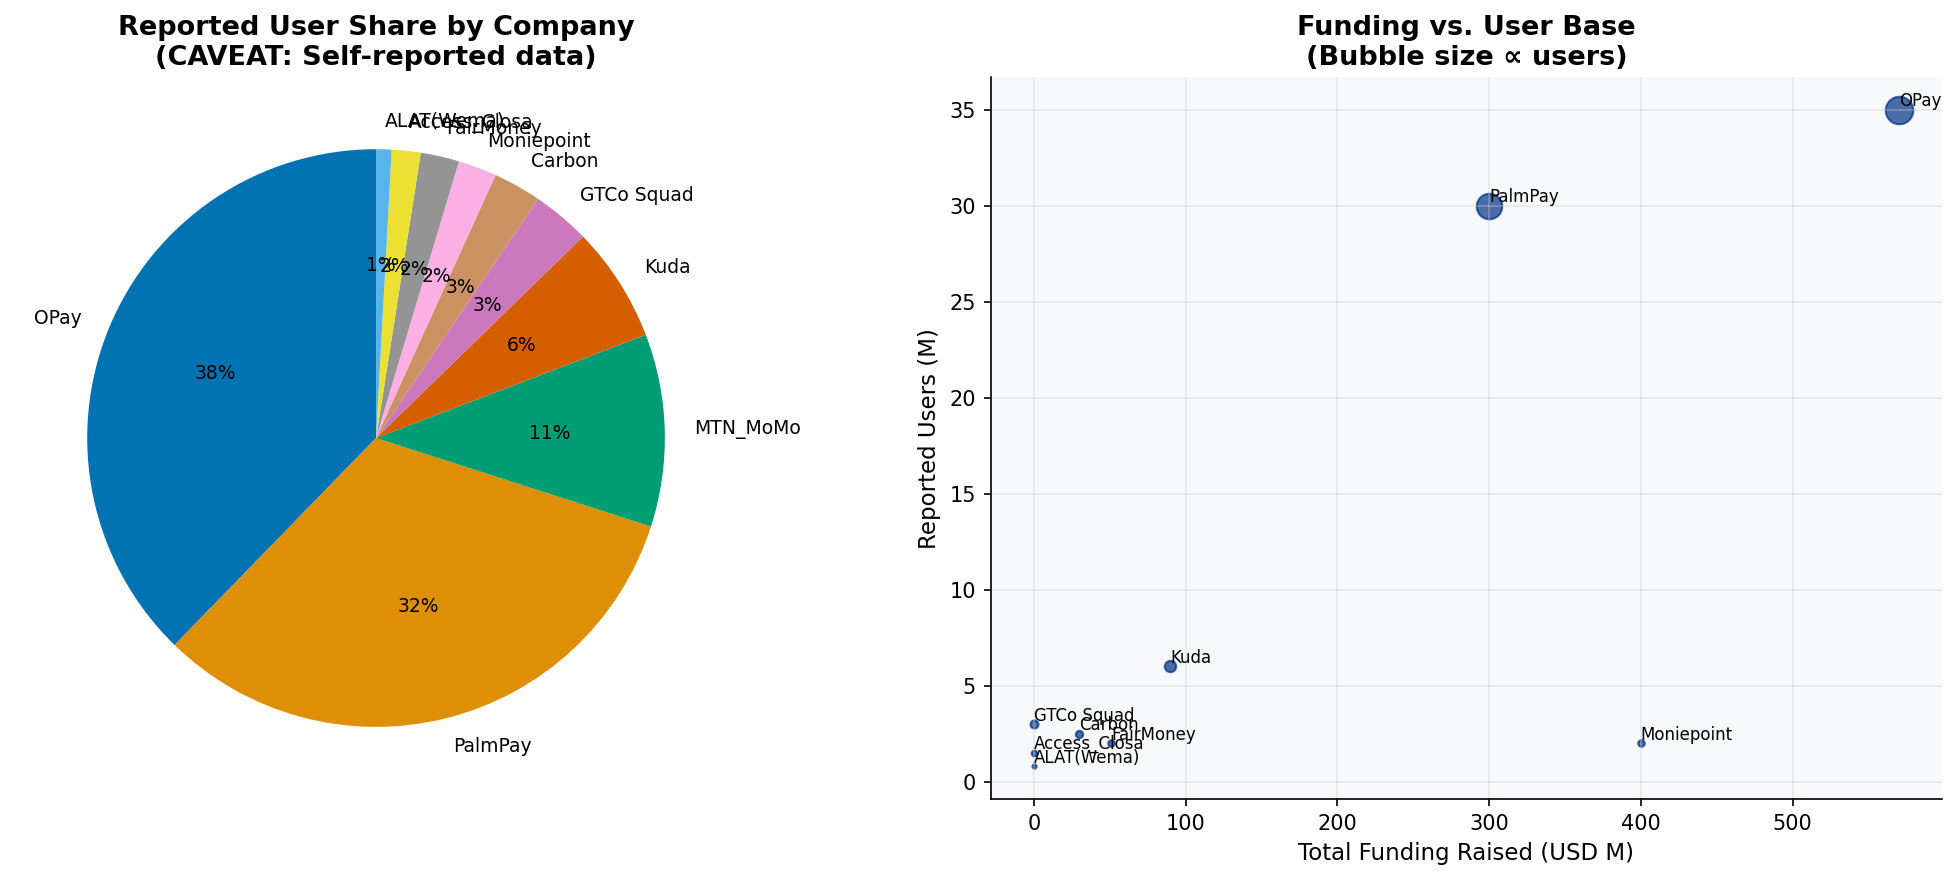

In [3]:
# Market share pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: User share by company
colors_pie = sns.color_palette("colorblind", len(df_sorted))
wedges, texts, autotexts = axes[0].pie(
    df_sorted['reported_users_m'],
    labels=df_sorted['company'],
    autopct='%1.0f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 9}
)
axes[0].set_title("Reported User Share by Company\n(CAVEAT: Self-reported data)")

# Right: Bubble chart — Users vs Funding
for _, row in df_comp.iterrows():
    if pd.notna(row['funding_usd_m']):
        axes[1].scatter(
            row['funding_usd_m'], row['reported_users_m'],
            s=row['reported_users_m'] * 5,
            alpha=0.7, color=BRAND_COLORS['primary']
        )
        axes[1].annotate(row['company'],
                          (row['funding_usd_m'], row['reported_users_m']),
                          fontsize=8, ha='left', va='bottom')

axes[1].set_xlabel("Total Funding Raised (USD M)")
axes[1].set_ylabel("Reported Users (M)")
axes[1].set_title("Funding vs. User Base\n(Bubble size ∝ users)")

plt.tight_layout()
save_figure(fig, "fig08_competitive_landscape.png")
plt.show()

## Revenue Model Comparison

I grouped competitors by revenue model to spot which models dominate.

In [4]:
model_counts = df_comp['revenue_model'].value_counts()
print("Revenue model distribution:")
print(model_counts)
print()

Revenue model distribution:
revenue_model
Trans          3
Lend+Trans     2
Lend           2
Trans+Ads      1
Trans+Lend     1
Trans+Float    1
Name: count, dtype: int64



## Porter's Five Forces Assessment

I scored each force on a 1–5 scale (1 = weak, 5 = strong) based on the data above.

,Force,Score (1–5),Assessment
0,Threat of New Entrants,3,"Moderate: CBN licensing creates barriers, but ..."
1,Bargaining Power of Buyers,3,"Moderate: High switching cost for agents, but ..."
2,Bargaining Power of Suppliers,2,Low: NIBSS / telco infrastructure is largely s...
3,Threat of Substitutes,3,Moderate: Informal cash economy is a substitut...
4,Competitive Rivalry,5,High: 10+ well-funded players competing for sa...


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig09_porters_five_forces.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig09_porters_five_forces.pdf


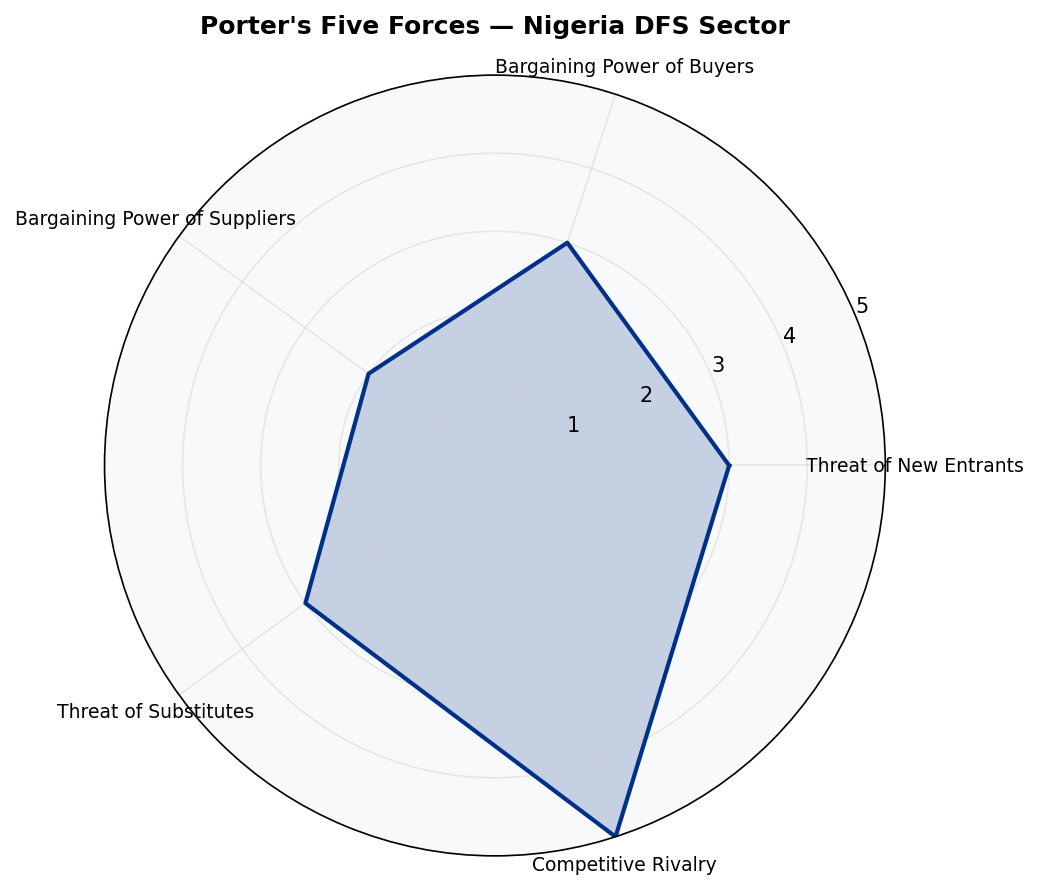

In [5]:
forces_data = {
    'Force': [
        'Threat of New Entrants',
        'Bargaining Power of Buyers',
        'Bargaining Power of Suppliers',
        'Threat of Substitutes',
        'Competitive Rivalry',
    ],
    'Score (1–5)': [3, 3, 2, 3, 5],
    'Assessment': [
        'Moderate: CBN licensing creates barriers, but capital is accessible to funded startups',
        'Moderate: High switching cost for agents, but consumer loyalty is low',
        'Low: NIBSS / telco infrastructure is largely standardised; multiple cloud providers',
        'Moderate: Informal cash economy is a substitute; hawala for remittances',
        'High: 10+ well-funded players competing for same smartphone-owning urban consumer',
    ]
}
df_forces = pd.DataFrame(forces_data)
display(df_forces)
df_forces.to_csv(tables_dir / "porters_five_forces.csv", index=False)

# Spider/radar chart
import numpy as np
categories = df_forces['Force'].tolist()
scores = df_forces['Score (1–5)'].tolist()
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
scores_plot = scores + [scores[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='polar'))
ax.plot(angles, scores_plot, color=BRAND_COLORS['primary'], linewidth=2)
ax.fill(angles, scores_plot, color=BRAND_COLORS['primary'], alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9)
ax.set_ylim(0, 5)
ax.set_title("Porter's Five Forces — Nigeria DFS Sector", size=12, fontweight='bold', pad=20)
plt.tight_layout()
save_figure(fig, "fig09_porters_five_forces.png")
plt.show()

## Competitive Benchmarking Table

In [6]:
bench = df_comp[['company', 'type', 'reported_users_m', 'funding_usd_m',
                  'agent_network_k', 'revenue_model', 'monthly_txn_ngn_bn']].copy()
bench.columns = ['Company', 'Type', 'Users (M)', 'Funding ($M)',
                  'Agents (K)', 'Revenue Model', 'Monthly Txn (₦Bn)']
bench = bench.sort_values('Users (M)', ascending=False)
display(bench)
bench.to_csv(tables_dir / "competitor_benchmarking.csv", index=False)
print(f"\nSaved: {tables_dir / 'competitor_benchmarking.csv'}")

,Company,Type,Users (M),Funding ($M),Agents (K),Revenue Model,Monthly Txn (₦Bn)
0,OPay,SuperApp,35.0,570.0,300.0,Trans+Ads,800.0
2,PalmPay,B2C,30.0,300.0,500.0,Trans,600.0
9,MTN_MoMo,MobileMoney,10.0,NaN,150.0,Trans+Float,90.0
3,Kuda,Neobank,6.0,90.0,NaN,Lend+Trans,120.0
7,GTCo Squad,Payments,3.0,0.0,NaN,Trans,200.0
4,Carbon,Neobank,2.5,30.0,NaN,Lend,50.0
1,Moniepoint,B2B/B2C,2.0,400.0,800.0,Trans+Lend,2100.0
5,FairMoney,Neobank,2.0,51.0,NaN,Lend,40.0
8,Access_Closa,Payments,1.5,0.0,NaN,Trans,80.0
6,ALAT(Wema),Neobank,0.8,0.0,NaN,Lend+Trans,35.0



Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\tables\competitor_benchmarking.csv
